# Optimal Out of Sample Learning 

My SSR theory becomes applicable to optimally facilitating out of sample learning 
by continuously deforming the sampling distribution. 
Starting with a fully fit model on MNIST digits 0 through 8 with a large dataset, 
we continuously sample more from digits 0 through 9 instead. 
Applying an SSR regularizer with optimally forecasted $\hat \pi$ should, in theory, 
facilitate most-optimal estimation on the new distribution, leveraging old information. 

In [1]:
## dependecies 

import random 
import tempfile 
import os 
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.nn import functional as F 
from tqdm.notebook import tqdm 
import matplotlib.pyplot as plt 

from ssr_agent import SSRAgent 
from replay_buffer import ReplayBuffer 

/anaconda/envs/azureml_py38/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
## constants 
BATCH_SIZE = 32 ## use 200 to see some separation. 32 is good for demonstrating SSR efficiency but has variance. 1000 illustrates assumption violation 
LEARNING_RATE = 0.001 
SMALL_SAMPLE_SIZE = 100 
PI_MAX = 0.99 

In [3]:
## load data 

train_dataset = datasets.MNIST(root='/tmp/data', train=True, transform=transforms.ToTensor(), download=True) 
test_dataset = datasets.MNIST(root='/tmp/data', train=False, transform=transforms.ToTensor()) 

class MnistSampler:
    'in-memory sampler facilitating smooth traversal of statistical manifold'
    def __init__(self, mnist_dataset): 
        self.data = [] 
        for image, label in mnist_dataset: 
            self.data.append((image, label)) 
            pass 
        pass 
    def sample(self, case_a_digits={0,1,2,3,4,5,6,7,8}, prob_case_b=.1): 
        '''Randomly samples one observation via two sampling strategies:
        - Case A: Sample only from `case_a_digits`, ie. 0 through 8. 
        - Case B: Sample from all MNIST digits. 
        Case B is sampled with probability `prob_case_b`. 
        Slowly increasing `prob_case_b` from 0 to 1 simulates a simple manifold traversal. 
        '''
        is_case_b = random.uniform(0, 1) <= prob_case_b 
        sample = None 
        n = len(self.data) 
        while sample is None: 
            idx = random.randint(0, n-1) 
            x, y = self.data[idx] 
            if not is_case_b: 
                # Case A: rejection sampling 
                if y in case_a_digits: 
                    sample = x, y 
                    ## implicit else: `sample` remains `None`, keep looping 
                    pass 
            else: 
                ## Case B: no rejection sampling 
                sample = x, y 
                pass 
            pass 
        return sample 
    def sample_n(self, n, case_a_digits={0,1,2,3,4,5,6,7,8}, prob_case_b=.1): 
        x_list = [] 
        y_list = [] 
        for _ in range(n): 
            x, y = self.sample(case_a_digits=case_a_digits, prob_case_b=prob_case_b) 
            x_list.append(x) 
            y_list.append(torch.tensor(y).reshape([1,1])) 
            pass 
        x = torch.cat(x_list) 
        y = torch.cat(y_list) 
        return x, y 
    def __len__(self): 
        return len(self.data) 
    pass 

train_sampler = MnistSampler(train_dataset) 
test_sampler = MnistSampler(test_dataset) 
## yes, literally just the nines. Use `prob_case_b = 1` or it will loop infinitely 
nines_sampler = MnistSampler(torch.utils.data.Subset(test_dataset, [idx for idx in range(len(test_dataset)) if test_dataset[idx][1] == 9]))

In [4]:
## define model 

class Buffer:
    ## stops parameter discovery 
    pass 

class DenseNet(SSRAgent):
    def __init__(self, replay_buffer=None, ssr_rank=5, lr=LEARNING_RATE, ssr_info_model=False): 
        if replay_buffer is None: 
            replay_buffer = ReplayBuffer(capacity=100000) ## need enough space for full MNIST training set 
            pass 
        super(DenseNet, self).__init__(ssr_rank=ssr_rank, replay_buffer=replay_buffer, ssr_info_model=ssr_info_model)
        self.features = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        self.__loss = nn.CrossEntropyLoss(reduction='mean') 
        self.optimizer = optim.Adam(self.parameters(), lr=lr) 
        self.buffer = Buffer() 
        self.buffer.prev_model = None 
        pass 
    def forward(self, x): 
        if x.shape[0] == 0: 
            return torch.tensor([]) 
        x = x.view(x.size(0), -1) 
        x = self.features(x) 
        return x 
    def update_loss_weights(self, weights): 
        weights = torch.FloatTensor(weights) 
        self.__loss.weight=weights 
        pass 
    def loss(self, data): 
        y_hat = self(data.x) 
        loss = self.__loss(y_hat, data.y.reshape([-1])) 
        if self.buffer.prev_model is not None: 
            ## y_hat = self.buffer.prev_model(data.x) 
            ## .5 = odds ratio (1-pi)/pi for pi = 2/3, close to observed 
            ## loss = loss - .5*(loss - self.buffer.prev_model.__loss(y_hat, data.y.reshape([-1]))) ## MISTAKE: use differences of predicted probs, not losses 
            y_hat_prev = self.buffer.prev_model(data.x) 
            kl_div = (y_hat - y_hat_prev) * F.softmax(y_hat, dim = 1) 
            kl_div = kl_div.sum(dim=1) 
            kl_div = kl_div.mean() 
            loss = loss + .4 * kl_div ## TODO use pi for a fair comparison 
            pass 
        return loss  
    def load_buffer(self, data_x, data_y): 
        self.replay_buffer.add(data_x, data_y) 
        pass 
    ## def memorize(...) ## already defined in SSRAgent parent class 
    def clear_buffer(self): 
        self.replay_buffer.clear() 
        pass 
    ## def fit(...) ## already defined in SSRAgent parent class  
    def acc(self, test_sampler=test_sampler, prob_case_b=0., batch_size=BATCH_SIZE): 
        self.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for _ in range(len(test_sampler)//batch_size): 
                x, y = test_sampler.sample_n(n=batch_size, prob_case_b=prob_case_b) 
                y_hat = self(x) 
                _, predicted = torch.max(y_hat.data, 1) 
                predicted = predicted.reshape([-1,1]) 
                total += y.size(0) 
                correct += (predicted == y).sum().item() 
                pass 
            pass 
        return correct / total ## acc 
    pass 

In [5]:
## initial fit, takes about 10 seconds on a CPU 

experimental_model = DenseNet() 
x, y = train_sampler.sample_n(5000, prob_case_b=0.) ## all Case A for initial fit 
experimental_model.load_buffer(x, y) 
tq = tqdm(range(1000))
for idx in tq: 
    if idx % 100 == 0: 
        acc = experimental_model.acc() 
        tq.set_description(f'accuracy: {round(acc,4)}') 
        pass 
    experimental_model.fit(iters=1, batch_size=BATCH_SIZE) 
    pass 
print(f'final accuracy: {round(acc,4)}') 

  0%|          | 0/1000 [00:00<?, ?it/s]

final accuracy: 0.9454


In [6]:
## create control models 
with tempfile.TemporaryDirectory() as tempdir: 
    ## copy from same model before differentiating under experimental conditions 
    baseline_memory_path = os.path.join(tempdir, 'baseline-memory.pt') 
    experimental_model.replay_buffer.save(baseline_memory_path) 
    ## condition 0: empty replay buffer, no memorization 
    condition_0_model = DenseNet() 
    condition_0_model.features.load_state_dict(experimental_model.features.state_dict())
    ## condition 1: full replay buffer, no memorization 
    condition_1_model = DenseNet() 
    condition_1_model.features.load_state_dict(experimental_model.features.state_dict())
    condition_1_model.replay_buffer.load(baseline_memory_path) 
    ## condition 2: ppo-like regularization, empty replay buffer with memory implicit in SSR  
    condition_2_model = DenseNet() 
    condition_2_model.features.load_state_dict(experimental_model.features.state_dict()) 
    ## condition 3: experimental SSR info model
    experimental_model_2 = DenseNet(ssr_info_model=True) 
    experimental_model_2.features.load_state_dict(experimental_model.features.state_dict()) 
    experimental_model_2.replay_buffer.load(baseline_memory_path) 
    pass 

/mnt/batch/tasks/shared/LS_root/mounts/clusters/wdurno2/code/Users/wdurno/notebooks/sufficiency-and-efficiency-in-deep-rl/transfer-learning/replay_buffer.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues relate

In [7]:
## memorize and discard, takes about 3 minutes on a CPU 

experimental_model.memorize() 
experimental_model.clear_buffer() 

  0%|          | 0/4 [00:00<?, ?it/s]

In [8]:
experimental_model_2.memorize() 
experimental_model_2.clear_buffer() 

  0%|          | 0/4 [00:00<?, ?it/s]

In [9]:
## efficiently traverse the statistical manifold 

def fit_continuous_deformation(model, memorize=True, pi_max=PI_MAX, ppo=False):
    acc_all_list = [] 
    acc_nines_list = [] 
    pi_list = [] 
    N_STEPS = 50 
    prob_case_b_list = [(idx+1)/N_STEPS for idx in range(N_STEPS)] 
    tq = tqdm(prob_case_b_list) 
    for prob_case_b in tq: 
        ## update loss weights 
        w = [1 - prob_case_b + 0.0001]*9 + [1 + prob_case_b + 0.0001]
        model.update_loss_weights(w)
        ## get data spiked with more and more 9s 
        x, y = train_sampler.sample_n(SMALL_SAMPLE_SIZE, prob_case_b=prob_case_b) 
        model.load_buffer(x, y) 
        ## fit, memorize, and clear 
        pi, _ = model.fit(iters=1, batch_size=SMALL_SAMPLE_SIZE, pi_min=.01, pi_max=pi_max) # pi_max=.9) ## trying small samples and small pi 
        ## print(f'DEBUG 1: pi: {round(float(pi),4)}, numerator: {round(float(model.dt_mean_trace_cov),4)}, denom: {round(float(model.dt_mean_norm_trend),4)}')
        if memorize: 
            model.memorize(disable_tqdm=True) 
            model.clear_buffer() 
            pass 
        ## get key performance indicators 
        acc_all = model.acc(test_sampler=test_sampler, prob_case_b=prob_case_b) 
        acc_nines = model.acc(test_sampler=nines_sampler, prob_case_b=1.) 
        tq.set_description(f'acc: {round(acc_all ,4)},  acc9: {round(acc_nines, 4)}, pi: {round(pi, 4)}') 
        ## record for plotting 
        acc_all_list.append(acc_all) 
        acc_nines_list.append(acc_nines) 
        pi_list.append(pi) 
        ## PPO-like regularizer 
        if ppo: 
            model.buffer.prev_model = DenseNet() 
            model.buffer.prev_model.features.load_state_dict(model.features.state_dict()) 
            model.buffer.prev_model.train() 
            pass 
        pass 
    return acc_all_list, acc_nines_list, pi_list  

In [10]:
exp_acc_all_list, exp_acc_nines_list, exp_pi_list = fit_continuous_deformation(experimental_model, memorize=True, ppo=False) 
_, exp_2_acc9, _ = fit_continuous_deformation(experimental_model_2, memorize=True, ppo=False) 
_, c0_acc9, _ = fit_continuous_deformation(condition_0_model, memorize=False, ppo=False)
_, c1_acc9, _ = fit_continuous_deformation(condition_1_model, memorize=False, ppo=False)
_, ppo_acc9, _ = fit_continuous_deformation(condition_2_model, memorize=False, ppo=True)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

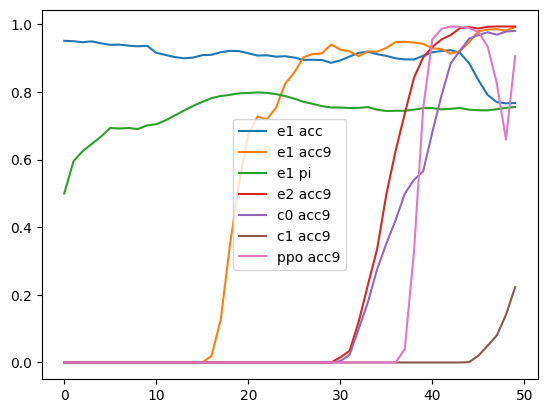

In [11]:
plt.plot(exp_acc_all_list, label='e1 acc') 
plt.plot(exp_acc_nines_list, label='e1 acc9') 
plt.plot(exp_pi_list, label='e1 pi') 
plt.plot(exp_2_acc9, label='e2 acc9') 
plt.plot(c0_acc9, label='c0 acc9')
plt.plot(c1_acc9, label='c1 acc9')
plt.plot(ppo_acc9, label='ppo acc9')
plt.legend() 
plt.show() 